# Desenvolvimento de Modelo para Classificação de Risco de Crédito
O objetivo deste projeto é o desenvolvimento de um modelo de Credit Scoring para estimar a probabilidade de inadimplência de tomadores de crédito. O processo de concessão de crédito fundamenta-se na análise de dados cadastrais e históricos financeiros para subsidiar a decisão das instituições financeiras entre a aprovação ou a negação de solicitações de empréstimo.

# 1. Fundamentação Teórica
O Credit Scoring é um modelo estatístico multivariado que utiliza variáveis independentes para estimar a probabilidade de um evento binário ocorrer. No contexto de risco, o evento monitorado é a inadimplência, definida pela incapacidade do tomador em cumprir com suas obrigações financeiras nos prazos estabelecidos.

O risco de crédito é intrínseco à atividade bancária, representando a probabilidade de que a expectativa de recebimento de um montante não se concretize. A precificação do crédito (taxas de juros) é diretamente influenciada por esse risco: quanto maior a probabilidade estimada de inadimplência, maior o risco assumido e, consequentemente, maior o custo do crédito.

## 1.1 Metodologia de Classificação
Para a classificação entre bons e maus pagadores, utiliza-se a Regressão Logística. Este modelo é amplamente adotado no setor financeiro devido a:

* Interpretabilidade: Permite compreender como cada variável (renda, idade, histórico) impacta diretamente no score final.

* Eficiência: Exige baixo poder computacional para processamento de grandes volumes de dados.

* Estabilidade: Oferece resultados consistentes e de fácil replicação em ambientes de produção.

A base de dados escolhida, originária da competição "Give Me Some Credit" do Kaggle, é um dos datasets mais utilizados para o estudo de risco de crédito devido ao seu volume (150.000 registros) e à natureza realista das suas variáveis.

**Observações Técnicas Relevantes**
- *Desbalanceamento de Classe*: Como identificado anteriormente, apenas ~6,7% da base representa o evento "Inadimplência". Isso exige cautela na escolha das métricas de performance do modelo.

- *Qualidade dos Dados*:
    - MonthlyIncome: Apresenta um volume significativo de dados ausentes (aproximadamente 29.731 linhas vazias), o que exigirá uma estratégia de imputação ou descarte.
    - NumberOfDependents: Também possui valores nulos (3.924 linhas), porém em menor escala.
    - Multicolinearidade: Variáveis como NumberOfTime30-59Days..., 60-89Days... e 90DaysLate tendem a ser altamente correlacionadas, o que deve ser analisado antes de treinar a Regressão Logística.

# 2. Diagnóstico Inicial dos Dados
Nesta etapa inicial, realiza-se o carregamento da base de dados e a verificação da sua integridade estrutural. Esta análise é determinante para estabelecer as diretrizes de pré-processamento, limpeza e engenharia de variáveis que precedem a modelagem.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dados = pd.read_csv('data/cs-training.csv', index_col=0)

# Verificação da estrutura do DataFrame
print("\n---- Estrutura e Tipagem dos Dados ---")
print(dados.info())


---- Estrutura e Tipagem dos Dados ---
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    1

In [3]:
# Dimensões do dataset
print(f"\nO dataset é composto por {dados.shape[0]} registros e {dados.shape[1]} variáveis.")

# Avaliação de registros duplicados
total_duplicados = dados.duplicated().sum()
print(f"\nRegistros duplicados identificados: {total_duplicados}")

# Avaliação de dados faltantes (nulos)
print("\n--- Identificação de Valores Ausentes ---")
nulos = dados.isnull().sum()
print(nulos[nulos > 0])

print("\nDistribuição da Variável Alvo (Inadimplência):")
print(dados['SeriousDlqin2yrs'].value_counts(normalize=True))


O dataset é composto por 150000 registros e 11 variáveis.

Registros duplicados identificados: 609

--- Identificação de Valores Ausentes ---
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

Distribuição da Variável Alvo (Inadimplência):
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [4]:
# Estruturação do dicionário de dados
dict_dados = {
    'Variável': [
        'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 
        'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 
        'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 
        'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 
        'NumberOfDependents'
    ],
    'Descrição': [
        'Inadimplência superior a 90 dias nos últimos 2 anos (Alvo)',
        'Saldo total em cartões e linhas de crédito sobre o limite total',
        'Idade do tomador de crédito',
        'Vezes que o cliente atrasou entre 30-59 dias (últimos 2 anos)',
        'Razão entre pagamentos mensais de dívidas e renda bruta',
        'Renda mensal bruta',
        'Número de empréstimos e linhas de crédito abertas',
        'Vezes que o cliente atrasou 90 dias ou mais',
        'Número de empréstimos hipotecários ou linhas de crédito imobiliário',
        'Vezes que o cliente atrasou entre 60-89 dias (últimos 2 anos)',
        'Número de dependentes na família'
    ],
    'Tipo': [
        'Binário', 'Percentual', 'Inteiro', 'Inteiro', 'Percentual', 
        'Decimal', 'Inteiro', 'Inteiro', 'Inteiro', 'Inteiro', 'Inteiro'
    ]
}

# Criação do DataFrame para visualização
df_dicionario = pd.DataFrame(dict_dados)

# Exibição da tabela formatada
display(df_dicionario)

,Variável,Descrição,Tipo
0,SeriousDlqin2yrs,Inadimplência superior a 90 dias nos últimos 2...,Binário
1,RevolvingUtilizationOfUnsecuredLines,Saldo total em cartões e linhas de crédito sob...,Percentual
2,age,Idade do tomador de crédito,Inteiro
3,NumberOfTime30-59DaysPastDueNotWorse,Vezes que o cliente atrasou entre 30-59 dias (...,Inteiro
4,DebtRatio,Razão entre pagamentos mensais de dívidas e re...,Percentual
5,MonthlyIncome,Renda mensal bruta,Decimal
6,NumberOfOpenCreditLinesAndLoans,Número de empréstimos e linhas de crédito abertas,Inteiro
7,NumberOfTimes90DaysLate,Vezes que o cliente atrasou 90 dias ou mais,Inteiro
8,NumberRealEstateLoansOrLines,Número de empréstimos hipotecários ou linhas d...,Inteiro
9,NumberOfTime60-89DaysPastDueNotWorse,Vezes que o cliente atrasou entre 60-89 dias (...,Inteiro


In [5]:
# Dicionário de mapeamento para tradução das colunas
colunas_traduzidas = {
    'SeriousDlqin2yrs': 'Inadimplente_2anos',
    'RevolvingUtilizationOfUnsecuredLines': 'Utilizacao_Limite',
    'age': 'Idade',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Atrasos_30_59_Dias',
    'DebtRatio': 'Razao_Debito',
    'MonthlyIncome': 'Renda_Mensal',
    'NumberOfOpenCreditLinesAndLoans': 'Linhas_Credito_Emprestimos_Abertos',
    'NumberOfTimes90DaysLate': 'Atrasos_90_Dias_Ou_Mais',
    'NumberRealEstateLoansOrLines': 'Emprestimos_Imobiliarios',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Atrasos_60_89_Dias',
    'NumberOfDependents': 'Numero_Dependentes'
}

# Aplicação da renomeação no DataFrame
dados = dados.rename(columns=colunas_traduzidas)

# Exibição das novas colunas para conferência
print("Colunas atualizadas com sucesso:")
print(dados.columns.tolist())

Colunas atualizadas com sucesso:
['Inadimplente_2anos', 'Utilizacao_Limite', 'Idade', 'Atrasos_30_59_Dias', 'Razao_Debito', 'Renda_Mensal', 'Linhas_Credito_Emprestimos_Abertos', 'Atrasos_90_Dias_Ou_Mais', 'Emprestimos_Imobiliarios', 'Atrasos_60_89_Dias', 'Numero_Dependentes']


# 3. Análise Estatística Descritiva
A análise das estatísticas descritivas é uma etapa crítica para identificar a distribuição das variáveis e a presença de possíveis anomalias. Para modelos de risco de crédito, a observação de valores mínimos, máximos e quartis permite identificar:

- Consistência dos Dados: Verificação de valores que fogem à realidade do negócio (ex: idade igual a zero ou negativa).

- Dispersão e Outliers: Identificação de valores extremos em variáveis como renda e utilização de crédito, que podem influenciar desproporcionalmente a Regressão Logística.

- Tendência Central: Avaliação da média e mediana para entender o perfil predominante da base de clientes.

Abaixo, apresenta-se o resumo estatístico transposto para facilitar a leitura das métricas de cada variável:

In [6]:
# Estatísticas básicas para variáveis numéricas
dados.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Inadimplente_2anos,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
Utilizacao_Limite,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Idade,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
Atrasos_30_59_Dias,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
Razao_Debito,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
Renda_Mensal,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
Linhas_Credito_Emprestimos_Abertos,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
Atrasos_90_Dias_Ou_Mais,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
Emprestimos_Imobiliarios,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
Atrasos_60_89_Dias,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


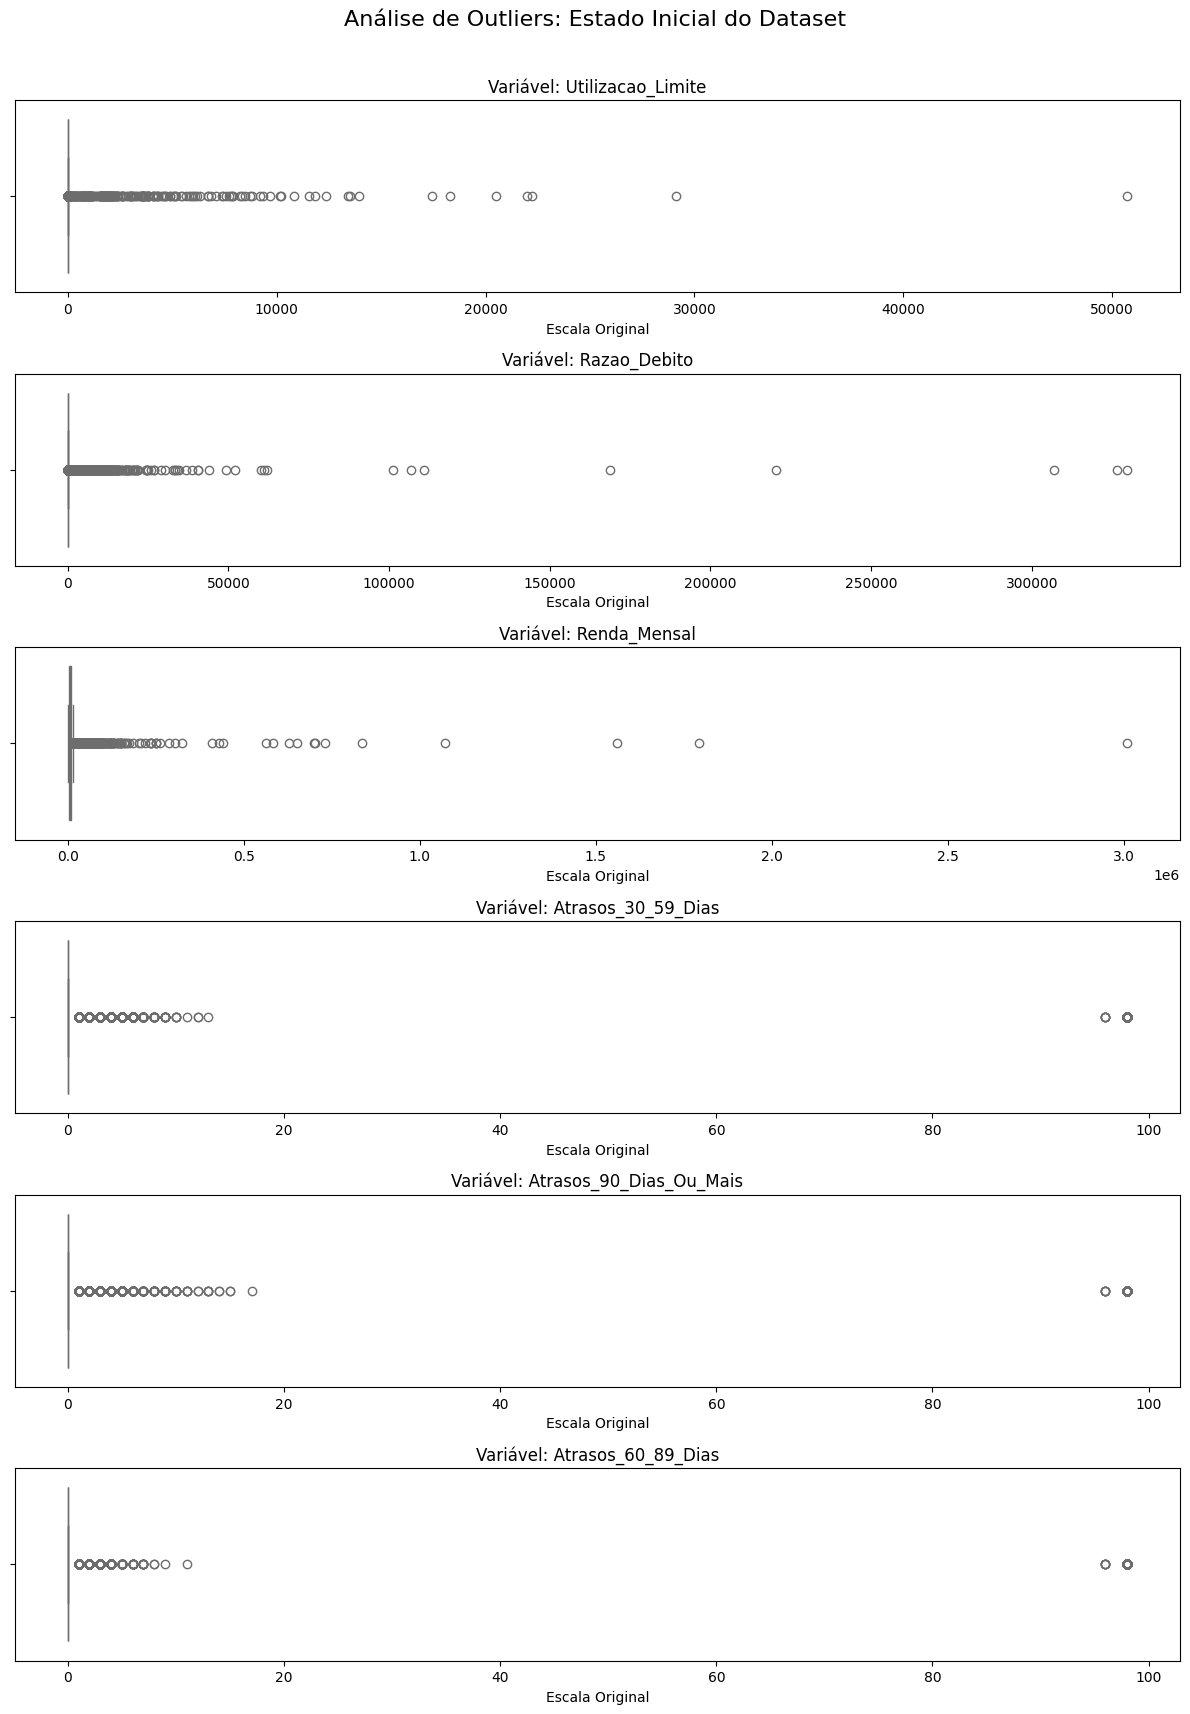

In [9]:
# Lista das variáveis atualizada com os nomes traduzidos
cols_discrepantes = [
    'Utilizacao_Limite', 
    'Razao_Debito', 
    'Renda_Mensal', 
    'Atrasos_30_59_Dias',
    'Atrasos_90_Dias_Ou_Mais',
    'Atrasos_60_89_Dias'
]

# Configuração da grade: uma linha para cada variável
fig, axes = plt.subplots(nrows=len(cols_discrepantes), ncols=1, figsize=(12, 18))
fig.suptitle('Análise de Outliers: Estado Inicial do Dataset', fontsize=16)

for i, col in enumerate(cols_discrepantes):
    # Verificamos se a coluna existe para evitar erro
    if col in dados.columns:
        sns.boxplot(x=dados[col], ax=axes[i], color='salmon')
        axes[i].set_title(f'Variável: {col}', fontsize=12)
        axes[i].set_xlabel('Escala Original')
    else:
        axes[i].text(0.5, 0.5, f'Coluna "{col}" não encontrada.', 
                     ha='center', va='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Os resultados apresentados no describe() confirmam que este dataset possui particularidades típicas de dados financeiros reais, apresentando desafios que precisam ser endereçados antes da modelagem.

Abaixo, apresento uma análise técnica dos pontos que demandam atenção, baseada nos valores observados:

# 4. Diagnóstico do Resumo Estatístico
A inspeção das métricas revela cenários que impactarão diretamente a performance da Regressão Logística:

**Valores Atípicos e Outliers**

    -RevolvingUtilizationOfUnsecuredLines: O valor máximo de 50.708 é fisicamente improvável para uma razão que deveria, em teoria, estar próxima de 1 (100%). Valores extremas nesta variável podem distorcer os coeficientes da regressão.

    -Age (Idade): O valor mínimo observado é 0. Como a concessão de crédito é restrita a maiores de idade, este registro é uma inconsistência cadastral evidente que precisará ser tratada.

    -DebtRatio: O valor máximo de 329.664 indica uma desproporção extrema entre dívida e renda, ou um erro de preenchimento, uma vez que a média está em 353.

    -MonthlyIncome: O valor máximo de 3.008.750 sugere a presença de clientes de altíssima renda, o que aumenta a variância dos dados.

**Dados Faltantes (Missing Values)**

    MonthlyIncome: Confirmamos a ausência de dados para cerca de 29.731 registros (150.000 - 120.269).

    NumberOfDependents: Há 3.924 registros sem informação de dependentes.

**Consistência de Atrasos**

As variáveis de atraso (30-59, 60-89 e 90+ dias) apresentam o mesmo valor máximo de 98. Na prática do mercado de crédito, o valor "98" é frequentemente utilizado como um código para "dado não disponível" ou "erro", e não necessariamente que o cliente atrasou 98 vezes. Precisaremos investigar a frequência desse número.
_______________________________________________________________________________________________________

Este diagnóstico permite traçar a estratégia para a próxima etapa: a Limpeza de Dados.

In [11]:
# 1. Tratamento de inconsistência na idade
# Remove registros onde a idade é zero (inconsistência cadastral)
dados = dados[dados['Idade'] > 0]

# 2. Imputação de valores ausentes
# Utiliza-se a mediana por ser menos sensível a outliers que a média
dados['Renda_Mensal'] = dados['Renda_Mensal'].fillna(dados['Renda_Mensal'].median())
dados['Numero_Dependentes'] = dados['Numero_Dependentes'].fillna(dados['Numero_Dependentes'].median())

# 3. Tratamento dos códigos de erro (96 e 98) nas variáveis de atraso
cols_atraso = [
    'Atrasos_30_59_Dias',
    'Atrasos_90_Dias_Ou_Mais',
    'Atrasos_60_89_Dias'
]

for col in cols_atraso:
    # Substituímos valores >= 96 pela mediana (geralmente 0) para remover o viés do código de erro
    mediana_col = dados[dados[col] < 96][col].median()
    dados.loc[dados[col] >= 96, col] = mediana_col

# 4. Tratamento de Outliers Extremos (Clipping/Winsorization)
# Definimos limites baseados no conhecimento de negócio e percentis altos
# Utilizacao_Limite: Capped em 1 (100% de uso)
dados.loc[dados['Utilizacao_Limite'] > 1, 'Utilizacao_Limite'] = 1

# Razao_Debito e Renda_Mensal: Capped no percentil 99 para evitar valores irreais
limite_debt = dados['Razao_Debito'].quantile(0.99)
dados.loc[dados['Razao_Debito'] > limite_debt, 'Razao_Debito'] = limite_debt

limite_renda = dados['Renda_Mensal'].quantile(0.99)
dados.loc[dados['Renda_Mensal'] > limite_renda, 'Renda_Mensal'] = limite_renda

# Verificação final de nulos e dimensões
print(f"Dimensões após limpeza: {dados.shape}")
print(f"Valores nulos restantes:\n{dados.isnull().sum().sum()}")

Dimensões após limpeza: (149999, 11)
Valores nulos restantes:
0


,count,mean,std,min,25%,50%,75%,max
Inadimplente_2anos,149999.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.00
Utilizacao_Limite,149999.0,0.319191,0.349478,0.0,0.029867,0.154176,0.559044,1.00
Idade,149999.0,52.295555,14.771298,21.0,41.000000,52.000000,63.000000,109.00
Atrasos_30_59_Dias,149999.0,0.245348,0.697231,0.0,0.000000,0.000000,0.000000,13.00
Razao_Debito,149999.0,316.551377,906.966934,0.0,0.175074,0.366503,0.868257,4979.08
Renda_Mensal,149999.0,6142.446263,3835.691425,0.0,3903.000000,5400.000000,7400.000000,23000.00
Linhas_Credito_Emprestimos_Abertos,149999.0,8.452776,5.145964,0.0,5.000000,8.000000,11.000000,58.00
Atrasos_90_Dias_Ou_Mais,149999.0,0.090294,0.485108,0.0,0.000000,0.000000,0.000000,17.00
Emprestimos_Imobiliarios,149999.0,1.018233,1.129772,0.0,0.000000,1.000000,2.000000,54.00
Atrasos_60_89_Dias,149999.0,0.064707,0.329790,0.0,0.000000,0.000000,0.000000,11.00


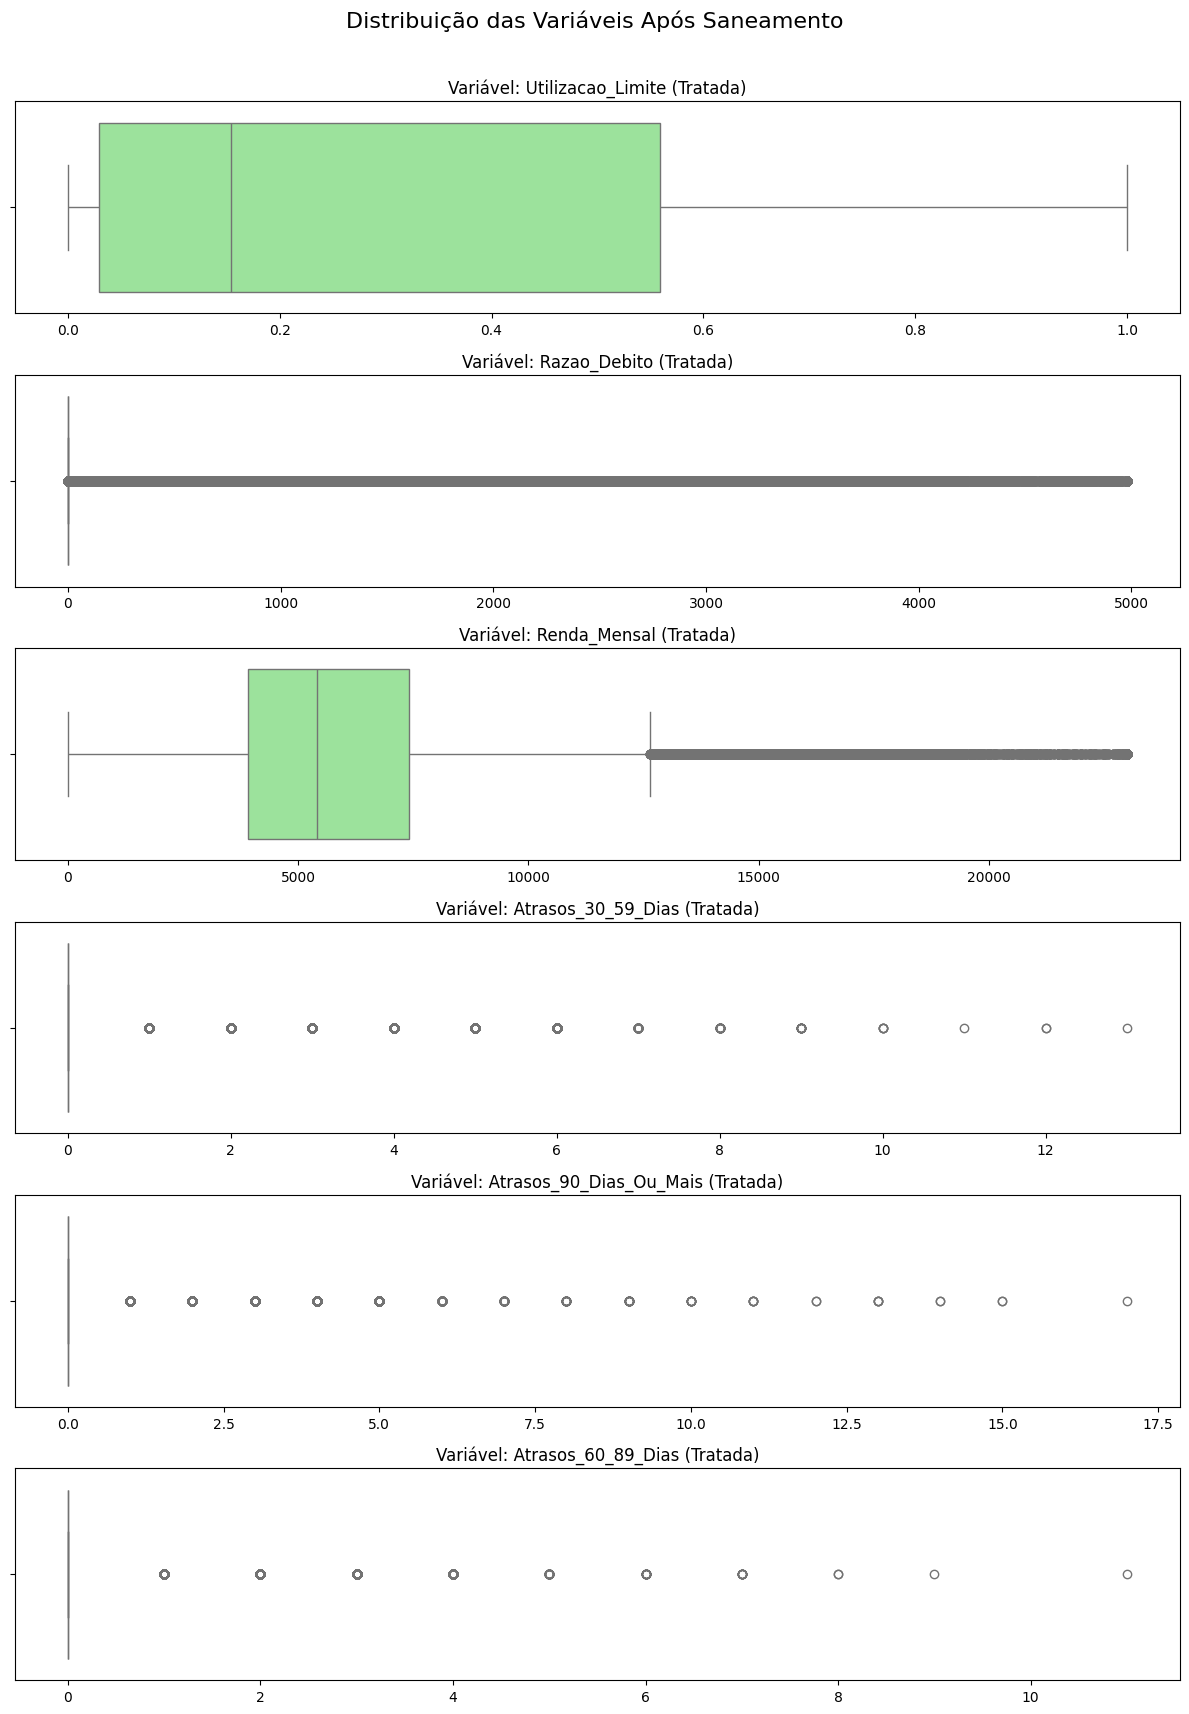

In [12]:
# Resumo estatístico pós-tratamento
display(dados.describe().transpose())

# Visualização da eficácia do tratamento de outliers
# Lista atualizada com os nomes em português
cols_ajustadas = [
    'Utilizacao_Limite', 
    'Razao_Debito', 
    'Renda_Mensal', 
    'Atrasos_30_59_Dias',
    'Atrasos_90_Dias_Ou_Mais',
    'Atrasos_60_89_Dias'
]

fig, axes = plt.subplots(nrows=len(cols_ajustadas), ncols=1, figsize=(12, 18))
fig.suptitle('Distribuição das Variáveis Após Saneamento', fontsize=16)

for i, col in enumerate(cols_ajustadas):
    sns.boxplot(x=dados[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Variável: {col} (Tratada)', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Os resultados obtidos após o saneamento demonstram uma melhoria significativa na qualidade e na consistência estatística da base de dados. O processo de limpeza foi eficaz para preparar o dataset para a modelagem de Regressão Logística, eliminando ruídos que poderiam distorcer as probabilidades de inadimplência.

# 5. Avaliação dos Resultados Pós-Saneamento

A comparação entre o estado inicial e o estado tratado revela avanços fundamentais em quatro pilares principais:

### 1. Eliminação de Inconsistências Críticas
* **Idade**: A correção do valor mínimo de **0 para 21 anos** normalizou a variável, garantindo que o modelo considere apenas indivíduos em idade legal para operações de crédito.
* **Códigos de Erro**: A substituição dos valores **98** (visíveis nos boxplots iniciais) reduziu drasticamente o valor máximo das variáveis de atraso (ex: de 98 para 13 em atrasos de 30-59 dias). Isso remove um viés artificial onde o modelo interpretaria um código de erro como uma contagem real de inadimplências.

### 2. Eficácia do Clipping (Limitação de Outliers)
As variáveis financeiras agora apresentam amplitudes condizentes com a realidade do mercado:
* **Utilização de Limite**: O valor máximo foi ajustado de **50.708 para 1.00**, refletindo corretamente a razão entre saldo e limite disponível.
* **Renda Mensal**: A aplicação do teto no percentil 99 reduziu o máximo de **3 milhões para 23.000**, preservando a variabilidade dos dados sem permitir que valores extremos desloquem a média de forma desproporcional.
* **Razão de Débito**: O limite máximo foi reduzido de **329.664 para 4.979**, mitigando o efeito de registros com preenchimento incorreto ou atípico.

### 3. Integridade e Imputação
* **Dados Ausentes**: O preenchimento das colunas de renda e dependentes com a mediana garantiu a manutenção dos **149.999 registros** (perda de apenas 1 registro devido ao filtro de idade), sem introduzir o viés que ocorreria caso utilizássemos a média em uma base com outliers.
* **Estabilidade da Classe Alvo**: A proporção da variável `Inadimplente_2anos` permaneceu estável em aproximadamente **6,68%**, confirmando que o saneamento limpou os dados sem alterar a natureza do problema de negócio.